In [1]:
%load_ext autoreload
%autoreload 2

import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from dvfm.data import sample_checkerboard, sample_moons, sample_spirals
from dvfm.ddpm import DDPMSchedule, ddpm_loss, ddpm_sample
from dvfm.flow_matching import flow_matching_loss
from dvfm.flow_matching import sample as fm_sample
from dvfm.models import TimeEmbeddingMLP
from dvfm.train import train_model

datasets = {
    "moons": sample_moons(50_000, seed=0),
    "spirals": sample_spirals(50_000, seed=0),
    "checkerboard": sample_checkerboard(50_000, seed=0),
}
schedule = DDPMSchedule()

CKPT_DIR = Path("../checkpoints")
CKPT_DIR.mkdir(exist_ok=True)
ASSETS_DIR = Path("../assets")
NUM_TRAIN_STEPS = 10_000

In [2]:
loss_fns = {
    "fm": flow_matching_loss,
    "ddpm": lambda model, x0: ddpm_loss(model, schedule, x0),
}

models = {}
for name, data in datasets.items():
    for method, loss_fn in loss_fns.items():
        path = CKPT_DIR / f"{method}_{name}.pt"
        torch.manual_seed(0)  # same initial weights for both methods
        model = TimeEmbeddingMLP()

        if path.exists():
            model.load_state_dict(torch.load(path))
            model.eval()
            print(f"Loaded {path.name}")
        else:
            print(f"--- Training {method} on {name} ---")
            train_model(model, data, loss_fn, num_steps=NUM_TRAIN_STEPS, cosine_schedule=True, log_every=5000)
            torch.save(model.state_dict(), path)

        models[(method, name)] = model

Loaded fm_moons.pt
Loaded ddpm_moons.pt
Loaded fm_spirals.pt
Loaded ddpm_spirals.pt
Loaded fm_checkerboard.pt
Loaded ddpm_checkerboard.pt


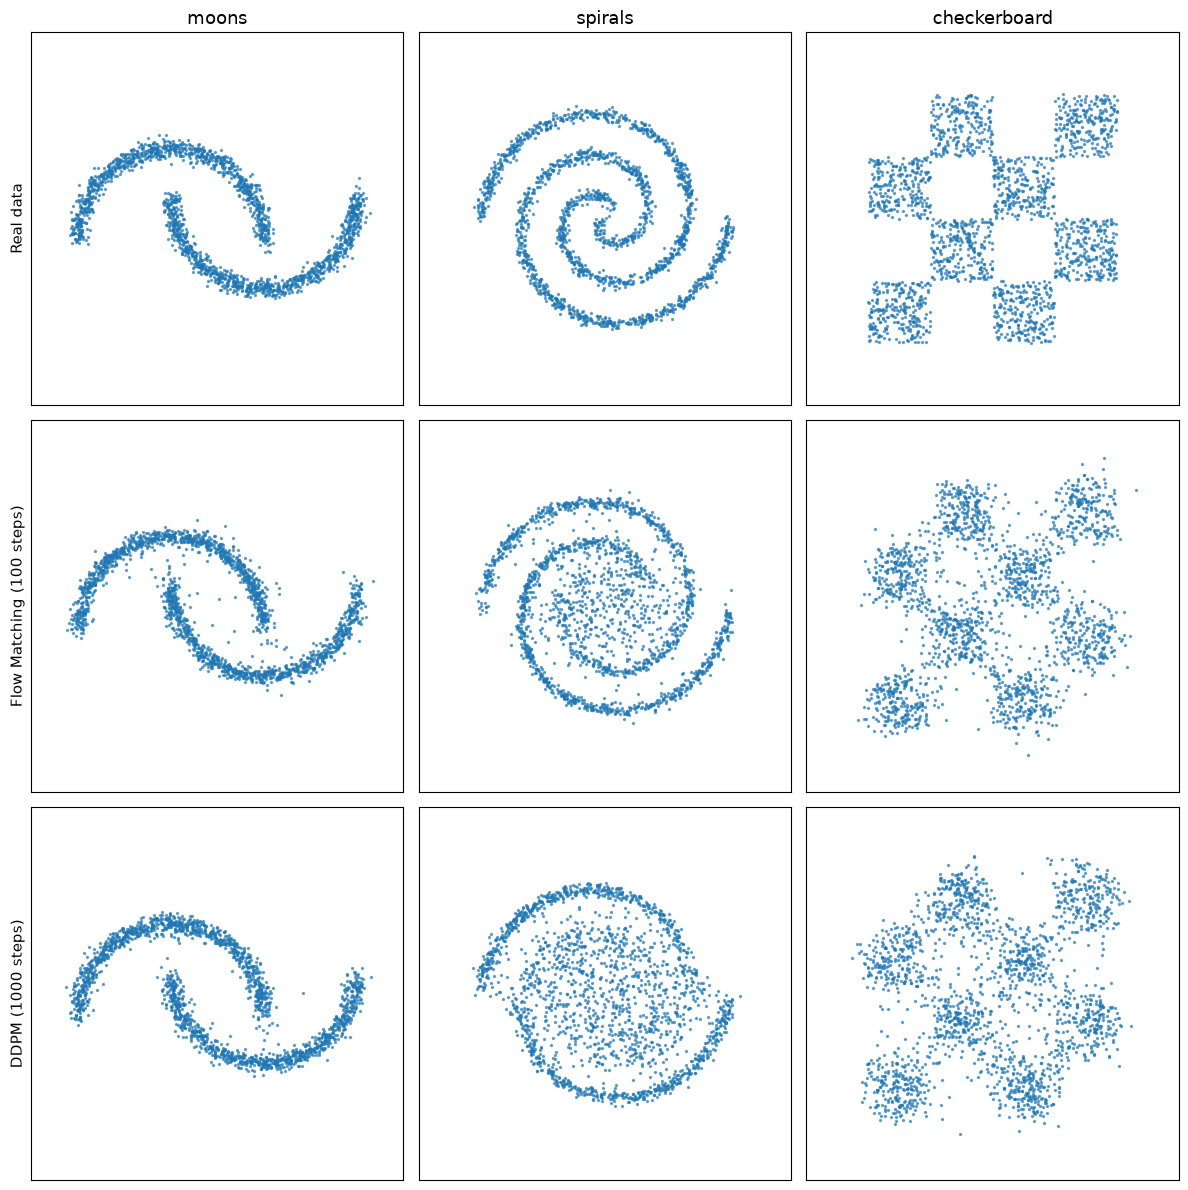

In [3]:
names = list(datasets)
rows = ["real", "fm", "ddpm"]
row_titles = {"real": "Real data", "fm": "Flow Matching (100 steps)", "ddpm": "DDPM (1000 steps)"}

fig, axes = plt.subplots(len(rows), len(names), figsize=(12, 12))
for col, name in enumerate(names):
    for row, method in enumerate(rows):
        torch.manual_seed(0)
        if method == "real":
            points = datasets[name][torch.randperm(len(datasets[name]))[:2000]]
        elif method == "fm":
            points = fm_sample(models[("fm", name)], 2000, num_steps=100)
        else:
            points = ddpm_sample(models[("ddpm", name)], schedule, 2000)

        ax = axes[row, col]
        ax.scatter(points[:, 0], points[:, 1], s=2, alpha=0.6)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(name, fontsize=13)
        if col == 0:
            ax.set_ylabel(row_titles[method], fontsize=11)

plt.tight_layout()
plt.savefig(ASSETS_DIR / "comparison_samples.png", dpi=150, bbox_inches="tight")
plt.show()

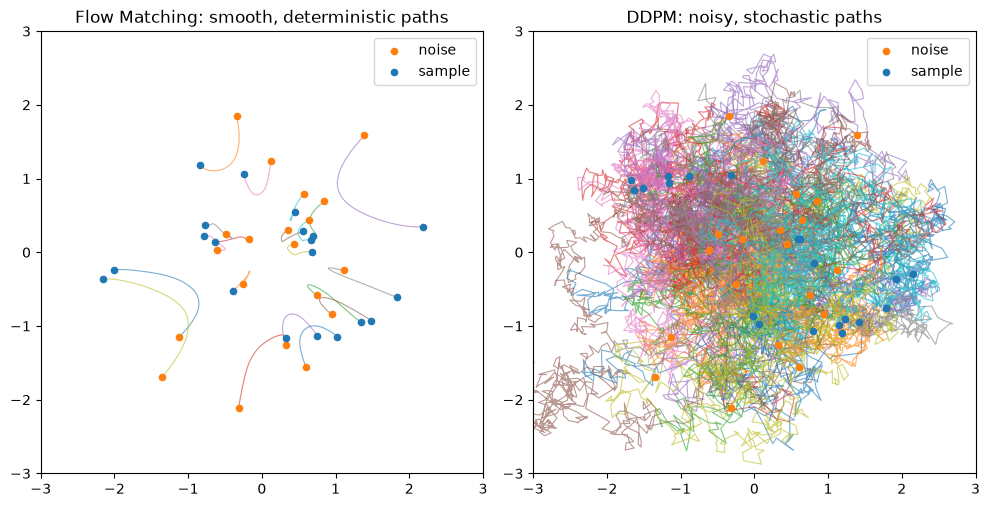

In [4]:
n_paths = 20

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, method in zip(axes, ["fm", "ddpm"]):
    torch.manual_seed(0)  # both samplers start from the SAME noise
    if method == "fm":
        _, traj = fm_sample(models[("fm", "moons")], 2000, num_steps=100, return_trajectory=True)
        title = "Flow Matching: smooth, deterministic paths"
    else:
        _, traj = ddpm_sample(models[("ddpm", "moons")], schedule, 2000, return_trajectory=True)
        title = "DDPM: noisy, stochastic paths"

    paths = torch.stack(traj)[:, :n_paths]  # (steps + 1, n_paths, 2)
    ax.plot(paths[:, :, 0], paths[:, :, 1], lw=0.8, alpha=0.6)
    ax.scatter(paths[0, :, 0], paths[0, :, 1], s=20, color="tab:orange", label="noise", zorder=3)
    ax.scatter(paths[-1, :, 0], paths[-1, :, 1], s=20, color="tab:blue", label="sample", zorder=3)
    ax.set_title(title)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig(ASSETS_DIR / "comparison_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
from dvfm.metrics import energy_distance

N = 2000
fm_steps = [1, 2, 5, 10, 20, 50, 100]
results = {}

for name, data in datasets.items():
    # Two independent sets of real points
    g = torch.Generator().manual_seed(1)
    reference = data[torch.randperm(len(data), generator=g)[:N]]
    other_real = data[torch.randperm(len(data), generator=g)[:N]]

    # Baseline: real vs real. No model can be meaningfully better than this.
    baseline = energy_distance(other_real, reference)

    fm_scores = []
    for steps in fm_steps:
        torch.manual_seed(0)
        generated = fm_sample(models[("fm", name)], N, num_steps=steps)
        fm_scores.append(energy_distance(generated, reference))

    torch.manual_seed(0)
    ddpm_score = energy_distance(ddpm_sample(models[("ddpm", name)], schedule, N), reference)

    results[name] = {"baseline": baseline, "fm": fm_scores, "ddpm": ddpm_score}

    print(f"--- {name} ---")
    print(f"  real vs real (baseline): {baseline:.4f}")
    for steps, score in zip(fm_steps, fm_scores):
        print(f"  FM   {steps:4d} steps: {score:.4f}")
    print(f"  DDPM 1000 steps: {ddpm_score:.4f}")

--- moons ---
  real vs real (baseline): 0.0012
  FM      1 steps: 0.8590
  FM      2 steps: 0.1960
  FM      5 steps: 0.0267
  FM     10 steps: 0.0077
  FM     20 steps: 0.0036
  FM     50 steps: 0.0024
  FM    100 steps: 0.0022
  DDPM 1000 steps: 0.0014
--- spirals ---
  real vs real (baseline): 0.0006
  FM      1 steps: 0.7974
  FM      2 steps: 0.1523
  FM      5 steps: 0.0250
  FM     10 steps: 0.0066
  FM     20 steps: 0.0029
  FM     50 steps: 0.0022
  FM    100 steps: 0.0022
  DDPM 1000 steps: 0.0043
--- checkerboard ---
  real vs real (baseline): 0.0009
  FM      1 steps: 0.9475
  FM      2 steps: 0.1894
  FM      5 steps: 0.0353
  FM     10 steps: 0.0109
  FM     20 steps: 0.0043
  FM     50 steps: 0.0022
  FM    100 steps: 0.0016
  DDPM 1000 steps: 0.0018


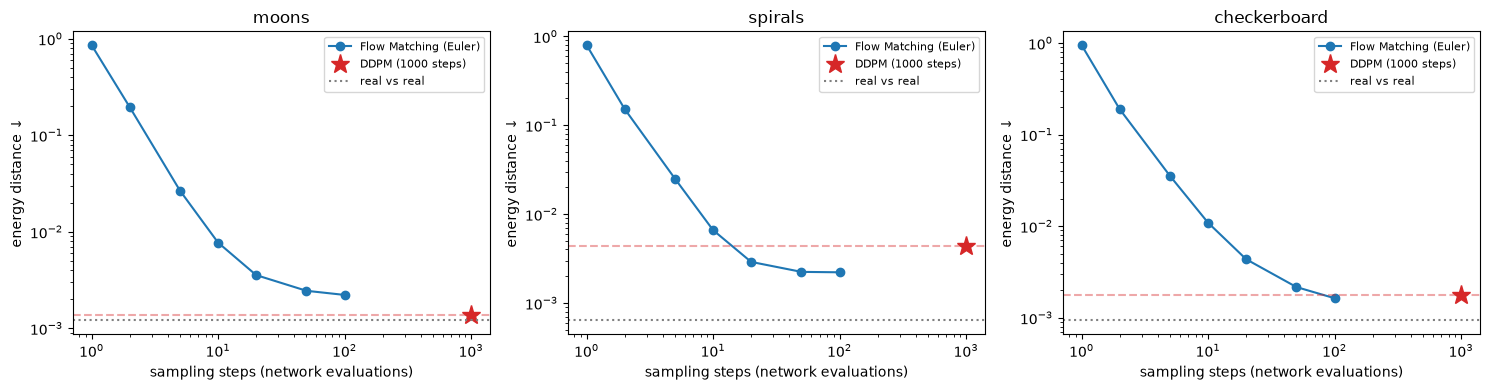

In [6]:
fig, axes = plt.subplots(1, len(results), figsize=(15, 4))

for ax, (name, r) in zip(axes, results.items()):
    ax.plot(fm_steps, r["fm"], "o-", label="Flow Matching (Euler)")
    ax.plot([1000], [r["ddpm"]], "*", markersize=14, color="tab:red", label="DDPM (1000 steps)")
    ax.axhline(r["ddpm"], color="tab:red", linestyle="--", alpha=0.4)
    ax.axhline(r["baseline"], color="gray", linestyle=":", label="real vs real")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("sampling steps (network evaluations)")
    ax.set_ylabel("energy distance ↓")
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ASSETS_DIR / "comparison_quality_vs_steps.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
def time_it(fn, repeats: int = 3) -> float:
    """Best of `repeats` runs, in seconds."""
    best = float("inf")
    for _ in range(repeats):
        start = time.perf_counter()
        fn()
        best = min(best, time.perf_counter() - start)
    return best


fm_model, ddpm_model = models[("fm", "moons")], models[("ddpm", "moons")]
timings = {
    "Flow Matching, 20 steps": time_it(lambda: fm_sample(fm_model, N, num_steps=20)),
    "Flow Matching, 100 steps": time_it(lambda: fm_sample(fm_model, N, num_steps=100)),
    "DDPM, 1000 steps": time_it(lambda: ddpm_sample(ddpm_model, schedule, N)),
}

ddpm_time = timings["DDPM, 1000 steps"]
print(f"| Method | Time for {N} samples | Speed-up vs DDPM |")
print("|---|---|---|")
for method, seconds in timings.items():
    print(f"| {method} | {seconds:.3f} s | {ddpm_time / seconds:.0f}x |")

| Method | Time for 2000 samples | Speed-up vs DDPM |
|---|---|---|
| Flow Matching, 20 steps | 0.076 s | 39x |
| Flow Matching, 100 steps | 0.362 s | 8x |
| DDPM, 1000 steps | 2.977 s | 1x |


In [8]:
from dvfm.ddpm import ddim_sample

for name, data in datasets.items():
    g = torch.Generator().manual_seed(1)
    reference = data[torch.randperm(len(data), generator=g)[:N]]  # same reference as before

    ddim_scores = []
    for steps in fm_steps:
        torch.manual_seed(0)
        generated = ddim_sample(models[("ddpm", name)], schedule, N, num_steps=steps)
        ddim_scores.append(energy_distance(generated, reference))
    results[name]["ddim"] = ddim_scores

    print(f"--- {name} ---")
    for steps, fm_score, ddim_score in zip(fm_steps, results[name]["fm"], ddim_scores):
        print(f"  {steps:4d} steps | FM {fm_score:.4f} | DDIM {ddim_score:.4f}")
    print(f"  DDPM 1000 steps: {results[name]['ddpm']:.4f}")

--- moons ---
     1 steps | FM 0.8590 | DDIM 0.9108
     2 steps | FM 0.1960 | DDIM 0.8988
     5 steps | FM 0.0267 | DDIM 0.1108
    10 steps | FM 0.0077 | DDIM 0.0181
    20 steps | FM 0.0036 | DDIM 0.0051
    50 steps | FM 0.0024 | DDIM 0.0030
   100 steps | FM 0.0022 | DDIM 0.0027
  DDPM 1000 steps: 0.0014
--- spirals ---
     1 steps | FM 0.7974 | DDIM 0.6792
     2 steps | FM 0.1523 | DDIM 0.6631
     5 steps | FM 0.0250 | DDIM 0.1031
    10 steps | FM 0.0066 | DDIM 0.0178
    20 steps | FM 0.0029 | DDIM 0.0051
    50 steps | FM 0.0022 | DDIM 0.0030
   100 steps | FM 0.0022 | DDIM 0.0029
  DDPM 1000 steps: 0.0043
--- checkerboard ---
     1 steps | FM 0.9475 | DDIM 0.7033
     2 steps | FM 0.1894 | DDIM 0.6958
     5 steps | FM 0.0353 | DDIM 0.0927
    10 steps | FM 0.0109 | DDIM 0.0211
    20 steps | FM 0.0043 | DDIM 0.0070
    50 steps | FM 0.0022 | DDIM 0.0028
   100 steps | FM 0.0016 | DDIM 0.0022
  DDPM 1000 steps: 0.0018


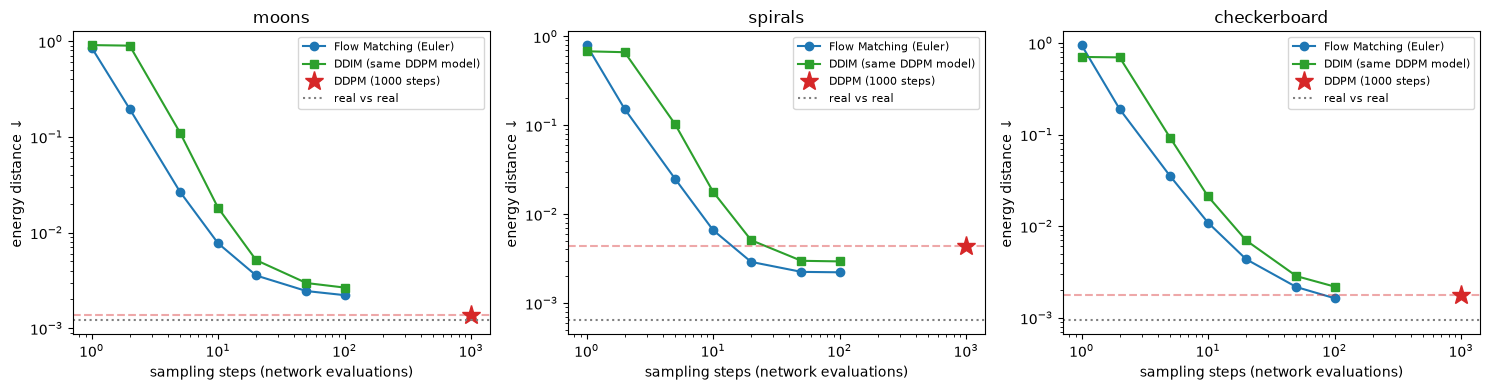

In [9]:
fig, axes = plt.subplots(1, len(results), figsize=(15, 4))

for ax, (name, r) in zip(axes, results.items()):
    ax.plot(fm_steps, r["fm"], "o-", label="Flow Matching (Euler)")
    ax.plot(fm_steps, r["ddim"], "s-", color="tab:green", label="DDIM (same DDPM model)")
    ax.plot([1000], [r["ddpm"]], "*", markersize=14, color="tab:red", label="DDPM (1000 steps)")
    ax.axhline(r["ddpm"], color="tab:red", linestyle="--", alpha=0.4)
    ax.axhline(r["baseline"], color="gray", linestyle=":", label="real vs real")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("sampling steps (network evaluations)")
    ax.set_ylabel("energy distance ↓")
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ASSETS_DIR / "comparison_quality_vs_steps.png", dpi=150, bbox_inches="tight")
plt.show()